# 📊 Clase 2 — Lectura y escritura de archivos Excel
## Obtención de datos y fundamentos de Numpy

**Situación:** Trabajas en el área de planificación energética de una empresa que gestiona el consumo eléctrico residencial en distintas regiones del país. Cada mes recibes el archivo `consumo_electrico_mensual.xlsx` con varias hojas — una por ciudad.

Tu jefatura necesita un **informe consolidado** con el total de consumo por ciudad y por tipo de cliente, y espera que el proceso esté **automatizado** para reutilizarlo cada mes.

> ⚠️ La hoja **Santiago** contiene errores intencionales para practicar diagnóstico.

---
## 📦 Librerías necesarias

> Si `openpyxl` no está instalado, ejecuta: `pip install openpyxl`

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import os

print('✅ Librerías cargadas')
print(f'pandas versión: {pd.__version__}')

✅ Librerías cargadas
pandas versión: 2.2.2


---
## PASO 1 — Explorar el archivo Excel

### 1.1 Identificar las hojas disponibles antes de leer

In [2]:
archivo = pd.ExcelFile('02. Apoyo ejercicio - Consumo eléctrico mensual.xlsx', engine='openpyxl')
print(type(archivo))
print('=== Hojas disponibles en el archivo ===')
print(archivo.sheet_names)
print(f'\nTotal de hojas: {len(archivo.sheet_names)}')

<class 'pandas.io.excel._base.ExcelFile'>
=== Hojas disponibles en el archivo ===
['Santiago', 'Valparaíso', 'Concepción', 'La Serena', 'Antofagasta']

Total de hojas: 5


### ✏️ Ejercicio 1.1 — Responde:

In [3]:
# ✏️ ¿Cuántas hojas tiene el archivo? ¿Coincide con las ciudades que esperabas?
respuesta_hojas = ""
print(respuesta_hojas)

### 1.2 Leer una hoja específica y revisar su estructura

In [4]:
# Leer solo la hoja de Santiago
df_stgo = pd.read_excel('02. Apoyo ejercicio - Consumo eléctrico mensual_1.xlsx',
                         sheet_name='Santiago',
                         engine='openpyxl')

print('=== Primeras filas ===')
print()
print('=== Información general ===')
df_stgo.head()

=== Primeras filas ===

=== Información general ===


,ID Cliente,Fecha Lectura,Tipo Cliente,Consumo (kWh),Tarifa ($/kWh),Monto Total ($)
0,SAN-C-1000,2024-05-05,Comercial,1828,116,212048
1,SAN-R-1001,2024-05-08,Residencial,212,113,23956
2,SAN-R-1002,2024-05-08,Residencial,N/D,127.1,⚠ Error: revisar D5
3,SAN-R-1003,2024-05-08,Residencial,370.2,137.6,50939.52
4,SAN-R-1004,2024-05-13,Residencial,216.5,133.1,28816.15


### 1.3 Detectar errores en la hoja Santiago

In [5]:
print('=== Valores únicos en Tipo Cliente ===')
print(df_stgo['Tipo Cliente'].unique())

print()
print('=== Valores no numéricos en Consumo (kWh) ===')
print(df_stgo[pd.to_numeric(df_stgo['Consumo (kWh)'], errors='coerce').isna()])

print()
print('=== Valores faltantes por columna ===')
print(df_stgo.isnull().sum())

=== Valores únicos en Tipo Cliente ===
['Comercial' 'Residencial' 'residencial' nan]

=== Valores no numéricos en Consumo (kWh) ===
    ID Cliente Fecha Lectura Tipo Cliente Consumo (kWh) Tarifa ($/kWh)  \
2   SAN-R-1002    2024-05-08  Residencial           N/D          127.1   
17  SAN-R-1017    2024-05-03  Residencial           NaN          135.1   

        Monto Total ($)  
2   ⚠ Error: revisar D5  
17                    0  

=== Valores faltantes por columna ===
ID Cliente         0
Fecha Lectura      1
Tipo Cliente       1
Consumo (kWh)      1
Tarifa ($/kWh)     0
Monto Total ($)    0
dtype: int64


### ✏️ Ejercicio 1.3 — Identifica y describe los errores:

In [6]:
# ✏️ Describe los errores encontrados en la hoja Santiago:
errores = """
Error 1 (valor no numérico):     
Error 2 (inconsistencia texto):  
Error 3 (valor faltante):        
"""
print(errores)


Error 1 (valor no numérico):     
Error 2 (inconsistencia texto):  
Error 3 (valor faltante):        



---
## PASO 2 — Leer todas las hojas y consolidar

### 2.1 Cargar todas las hojas con `sheet_name=None`

In [7]:
hojas = pd.read_excel('02. Apoyo ejercicio - Consumo eléctrico mensual_1.xlsx',
                       sheet_name=None,
                       engine='openpyxl')

print('=== Hojas cargadas y sus dimensiones ===')
for nombre, df in hojas.items():
    print(f'  {nombre:<15} → {df.shape[0]} filas x {df.shape[1]} columnas')

=== Hojas cargadas y sus dimensiones ===
  Santiago        → 41 filas x 6 columnas
  Valparaíso      → 32 filas x 6 columnas
  Concepción      → 32 filas x 6 columnas
  La Serena       → 27 filas x 6 columnas
  Antofagasta     → 27 filas x 6 columnas


### 2.2 Consolidar todas las hojas en un único DataFrame

In [8]:
df_list = []

for nombre_hoja, df in hojas.items():
    df = df.copy()
    df['ciudad'] = nombre_hoja       # Agregar columna con nombre de ciudad
    df_list.append(df)

consolidado = pd.concat(df_list, ignore_index=True)

print(f'Dataset consolidado: {consolidado.shape[0]} filas x {consolidado.shape[1]} columnas')
print()
print(consolidado.head(8))

Dataset consolidado: 159 filas x 16 columnas

   ID Cliente Fecha Lectura Tipo Cliente Consumo (kWh) Tarifa ($/kWh)  \
0  SAN-C-1000    2024-05-05    Comercial          1828            116   
1  SAN-R-1001    2024-05-08  Residencial           212            113   
2  SAN-R-1002    2024-05-08  Residencial           N/D          127.1   
3  SAN-R-1003    2024-05-08  Residencial         370.2          137.6   
4  SAN-R-1004    2024-05-13  Residencial         216.5          133.1   
5  SAN-C-1005    2024-05-02    Comercial          1024          120.1   
6  SAN-C-1006    2024-05-12    Comercial        1654.2           96.5   
7  SAN-R-1007    2024-05-12  Residencial           282          122.7   

       Monto Total ($)    ciudad  \
0               212048  Santiago   
1                23956  Santiago   
2  ⚠ Error: revisar D5  Santiago   
3             50939.52  Santiago   
4             28816.15  Santiago   
5             122982.4  Santiago   
6             159630.3  Santiago   
7       

### 2.3 Limpiar el dataset consolidado

In [9]:
# Normalizar nombres de columna
consolidado.columns = consolidado.columns.str.strip()

# Estandarizar 'Tipo Cliente' (capitalizar)
consolidado['Tipo Cliente'] = consolidado['Tipo Cliente'].str.title()

# Convertir consumo a numérico (errores → NaN)
consolidado['Consumo (kWh)'] = pd.to_numeric(consolidado['Consumo (kWh)'], errors='coerce')
consolidado['Tarifa ($/kWh)'] = pd.to_numeric(consolidado['Tarifa ($/kWh)'], errors='coerce')

# Eliminar filas sin consumo válido
n_antes = len(consolidado)
consolidado = consolidado.dropna(subset=['Consumo (kWh)'])
n_despues = len(consolidado)

print(f'Filas antes de limpieza:  {n_antes}')
print(f'Filas después de limpieza: {n_despues}')
print(f'Filas eliminadas:          {n_antes - n_despues}')
print()
print('Tipos de cliente únicos:', consolidado['Tipo Cliente'].unique())

Filas antes de limpieza:  159
Filas después de limpieza: 39
Filas eliminadas:          120

Tipos de cliente únicos: ['Comercial' 'Residencial' nan]


### ✏️ Ejercicio 2.3 — Reflexión:

In [10]:
# ✏️ ¿Por qué es importante agregar la columna 'ciudad' antes de consolidar?
respuesta_ciudad = ""

# ✏️ ¿Qué pasaría si no estandarizáramos 'Tipo Cliente' antes de agrupar?
respuesta_estandar = ""

print(respuesta_ciudad)
print(respuesta_estandar)

---
## PASO 3 — Agrupar y analizar

### 3.1 Total de consumo por ciudad y tipo de cliente

In [11]:
resumen = (
    consolidado
    .groupby(['ciudad', 'Tipo Cliente'])['Consumo (kWh)']
    .sum()
    .reset_index()
    .rename(columns={'Consumo (kWh)': 'consumo_total_kWh'})
)

print('=== Consumo total por ciudad y tipo de cliente ===')
print(resumen.to_string(index=False))

=== Consumo total por ciudad y tipo de cliente ===
  ciudad Tipo Cliente  consumo_total_kWh
Santiago    Comercial            38228.5
Santiago  Residencial             8829.2


### ✏️ Ejercicio 3.1 — Analiza:

In [12]:
# ✏️ ¿Qué ciudad tiene el mayor consumo comercial?
mayor_comercial = resumen[resumen['Tipo Cliente'] == 'Comercial'].nlargest(1, 'consumo_total_kWh')
print('Ciudad con mayor consumo comercial:')
print(mayor_comercial.to_string(index=False))

print()

# ✏️ ¿Hay diferencia importante entre tipos de cliente?
diferencia = resumen.groupby('Tipo Cliente')['consumo_total_kWh'].sum()
print('Consumo total por tipo:')
print(diferencia)

# ✏️ Escribe tu conclusión:
conclusion = ""
print('\nConclusión:', conclusion)

Ciudad con mayor consumo comercial:
  ciudad Tipo Cliente  consumo_total_kWh
Santiago    Comercial            38228.5

Consumo total por tipo:
Tipo Cliente
Comercial      38228.5
Residencial     8829.2
Name: consumo_total_kWh, dtype: float64

Conclusión: 


### 3.2 Visualización

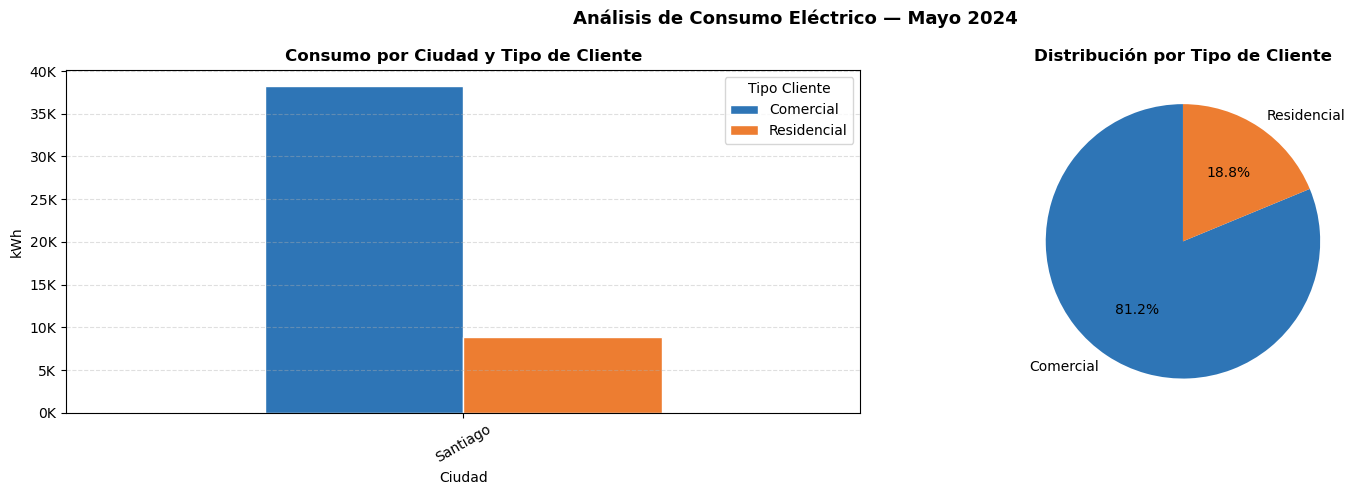

✅ Gráfico guardado como consumo_grafico.png


In [13]:
pivot_vis = resumen.pivot(index='ciudad', columns='Tipo Cliente', values='consumo_total_kWh').fillna(0)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Análisis de Consumo Eléctrico — Mayo 2024', fontsize=13, fontweight='bold')

# Gráfico 1: Barras apiladas por ciudad
pivot_vis.plot(kind='bar', ax=axes[0], color=['#2E75B6','#ED7D31'], edgecolor='white')
axes[0].set_title('Consumo por Ciudad y Tipo de Cliente', fontweight='bold')
axes[0].set_xlabel('Ciudad')
axes[0].set_ylabel('kWh')
axes[0].tick_params(axis='x', rotation=30)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
axes[0].legend(title='Tipo Cliente')
axes[0].grid(axis='y', linestyle='--', alpha=0.4)

# Gráfico 2: Pie por tipo de cliente
totales = resumen.groupby('Tipo Cliente')['consumo_total_kWh'].sum()
axes[1].pie(totales.values, labels=totales.index, autopct='%1.1f%%',
             colors=['#2E75B6','#ED7D31'], startangle=90)
axes[1].set_title('Distribución por Tipo de Cliente', fontweight='bold')

plt.tight_layout()
plt.savefig('consumo_grafico.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Gráfico guardado como consumo_grafico.png')

---
## PASO 4 — Exportar a Excel con múltiples hojas

### 4.1 Exportación básica

In [14]:
# Exportación básica del resumen
resumen.to_excel('resumen_consumo.xlsx', index=False, engine='openpyxl')
print('✅ resumen_consumo.xlsx generado')

✅ resumen_consumo.xlsx generado


### 4.2 Exportar con múltiples hojas usando `ExcelWriter`

In [15]:
# Resumen por ciudad (total general)
resumen_ciudad = (
    consolidado.groupby('ciudad')['Consumo (kWh)']
    .agg(total_kWh='sum', promedio_kWh='mean', registros='count')
    .round(1)
    .reset_index()
    .sort_values('total_kWh', ascending=False)
)

# Generar nombre con fecha dinámica
from datetime import datetime
nombre_archivo = f"informe_consumo_{datetime.today().strftime('%Y-%m-%d')}.xlsx"

# Verificar si ya existe
if os.path.exists(nombre_archivo):
    print(f'⚠️  Atención: {nombre_archivo} ya existe. Se sobreescribirá.')

with pd.ExcelWriter(nombre_archivo, engine='openpyxl') as writer:
    resumen.to_excel(writer, sheet_name='Por Ciudad y Tipo', index=False)
    resumen_ciudad.to_excel(writer, sheet_name='Resumen Ciudades', index=False)
    consolidado.to_excel(writer, sheet_name='Datos Consolidados', index=False)

print(f'✅ {nombre_archivo} generado con 3 hojas')

✅ informe_consumo_2026-06-22.xlsx generado con 3 hojas


### 4.3 Verificar el archivo generado

In [16]:
archivo_check = pd.ExcelFile(nombre_archivo, engine='openpyxl')
print('=== Hojas en el archivo exportado ===')
print(archivo_check.sheet_names)

print()
print('=== Verificación hoja "Por Ciudad y Tipo" ===')
df_check = pd.read_excel(nombre_archivo, sheet_name='Por Ciudad y Tipo', engine='openpyxl')
print(df_check)

print()
print('=== Verificación hoja "Resumen Ciudades" ===')
df_check2 = pd.read_excel(nombre_archivo, sheet_name='Resumen Ciudades', engine='openpyxl')
print(df_check2)

=== Hojas en el archivo exportado ===
['Por Ciudad y Tipo', 'Resumen Ciudades', 'Datos Consolidados']

=== Verificación hoja "Por Ciudad y Tipo" ===
     ciudad Tipo Cliente  consumo_total_kWh
0  Santiago    Comercial            38228.5
1  Santiago  Residencial             8829.2

=== Verificación hoja "Resumen Ciudades" ===
     ciudad  total_kWh  promedio_kWh  registros
0  Santiago    94115.4        2413.2         39


### 4.4 Exportar columnas específicas

In [17]:
# Solo las columnas esenciales para gerencia
consolidado[['ciudad', 'Tipo Cliente', 'Consumo (kWh)', 'Monto Total ($)']].to_excel(
    'reporte_gerencia.xlsx',
    index=False,
    engine='openpyxl'
)
print('✅ reporte_gerencia.xlsx generado (solo columnas clave)')

✅ reporte_gerencia.xlsx generado (solo columnas clave)


---
## PASO 5 — Preguntas de reflexión

In [18]:
# ✏️ 1. ¿Qué ventajas tiene este enfoque vs. copiar y pegar en Excel manualmente?
ventajas = ""

# ✏️ 2. ¿Cómo cambiarías el código si el archivo tuviera más de 10 hojas o nombres no estandarizados?
adaptacion = ""

# ✏️ 3. ¿Qué otras variables podrían ser relevantes para la jefatura en este tipo de reportes?
otras_variables = ""

# ✏️ 4. ¿Qué errores podrían ocurrir si no verificamos el contenido antes de escribir?
riesgos = ""

print('--- REFLEXIONES ---')
print(f'1. Ventajas: {ventajas}')
print(f'2. Adaptación: {adaptacion}')
print(f'3. Otras variables: {otras_variables}')
print(f'4. Riesgos: {riesgos}')

--- REFLEXIONES ---
1. Ventajas: 
2. Adaptación: 
3. Otras variables: 
4. Riesgos: 


---
## PASO 6 — Desafío: leer columnas específicas

Practica los parámetros avanzados de `read_excel()`:

In [19]:
# ✏️ Lee SOLO las columnas ID Cliente, Tipo Cliente y Consumo (kWh) de la hoja Valparaíso
# Usa el parámetro usecols

# df_valpo = pd.read_excel(
#     'consumo_electrico_mensual.xlsx',
#     sheet_name='???',
#     usecols=['???', '???', '???'],
#     engine='openpyxl'
# )
# print(df_valpo.head())
# print(f'Shape: {df_valpo.shape}')

print('Descomenta y completa el código para ejecutar el desafío.')

Descomenta y completa el código para ejecutar el desafío.


In [20]:
# ✏️ DESAFÍO EXTRA: Crea un loop que lea solo las 5 primeras filas de cada hoja
# y muestre el promedio de consumo por hoja

# for hoja in archivo.sheet_names:
#     df_temp = pd.read_excel(..., sheet_name=hoja, nrows=5, engine='openpyxl')
#     print(f'{hoja}: promedio consumo = {df_temp["Consumo (kWh)"].mean():.1f} kWh')

print('Descomenta y completa el código para ejecutar el desafío extra.')

Descomenta y completa el código para ejecutar el desafío extra.


---
## 📋 Resumen de parámetros y buenas prácticas

| Función | Parámetro | Uso |
|---------|-----------|-----|
| `ExcelFile()` | `engine='openpyxl'` | Leer .xlsx de forma segura |
| `.sheet_names` | — | Listar hojas antes de cargar |
| `read_excel()` | `sheet_name='Nombre'` | Leer hoja específica |
| `read_excel()` | `sheet_name=None` | Leer todas las hojas (dict) |
| `read_excel()` | `usecols=['col1','col2']` | Cargar solo columnas necesarias |
| `read_excel()` | `nrows=10` | Leer solo N filas (vista previa) |
| `to_excel()` | `index=False` | No escribir el índice |
| `ExcelWriter` | `sheet_name='Hoja'` | Múltiples hojas en un archivo |

> 💡 **Regla de oro:** Siempre declara `engine='openpyxl'` explícitamente para archivos `.xlsx`. Evita `xlrd` con archivos modernos — solo sirve para `.xls` legados.

> 💡 **Automatización mensual:** Envuelve todo el flujo en una función `def procesar_consumo(ruta_archivo):` y llámala con el nuevo archivo cada mes.